In [1]:
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
body_df = pd.read_csv(data_url + "body_fat.csv", index_col='ID')
body_df

,Sex,Age,Height,Weight,Body fat percentage
ID,,,,,
F001,F,37.0,161.4,62.9,32.8
F002,F,26.0,168.1,56.1,31.5
F003,F,39.0,163.4,53.2,25.2
F004,F,30.0,164.1,49.4,21.8
F005,F,44.0,152.9,51.9,24.2
...,...,...,...,...,...
M496,M,48.0,176.4,95.5,29.7
M497,M,75.0,157.4,63.9,34.9
M498,M,58.0,167.3,68.0,15.6


In [7]:
body_df.corr(numeric_only=True)

,Age,Height,Weight,Body fat percentage
Age,1.000000,-0.368255,-0.038761,0.337647
Height,-0.368255,1.000000,0.658913,-0.569835
Weight,-0.038761,0.658913,1.000000,-0.001381
Body fat percentage,0.337647,-0.569835,-0.001381,1.000000


In [8]:
body_df.groupby('Sex').corr(numeric_only=True)

Age    Height    Weight  Body fat percentage
Sex                                                                       
F   Age                  1.000000 -0.517697  0.151228             0.409435
    Height              -0.517697  1.000000  0.164666            -0.407790
    Weight               0.151228  0.164666  1.000000             0.566064
    Body fat percentage  0.409435 -0.407790  0.566064             1.000000
M   Age                  1.000000 -0.509665 -0.108904             0.308942
    Height              -0.509665  1.000000  0.381675            -0.277947
    Weight              -0.108904  0.381675  1.000000             0.497619
    Body fat percentage  0.308942 -0.277947  0.497619             1.000000

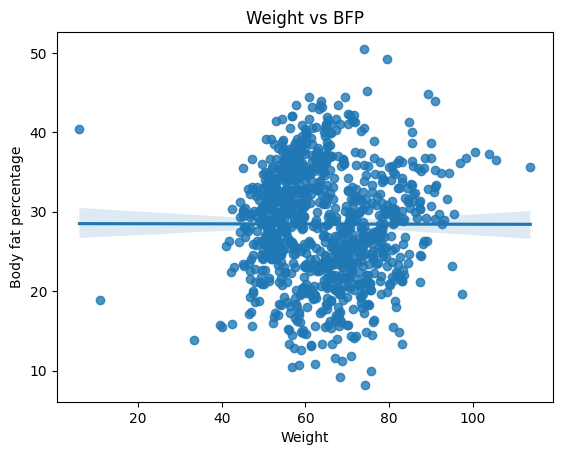

In [9]:
sns.regplot(data=body_df, x='Weight',y='Body fat percentage')
plt.title("Weight vs BFP")
plt.show()

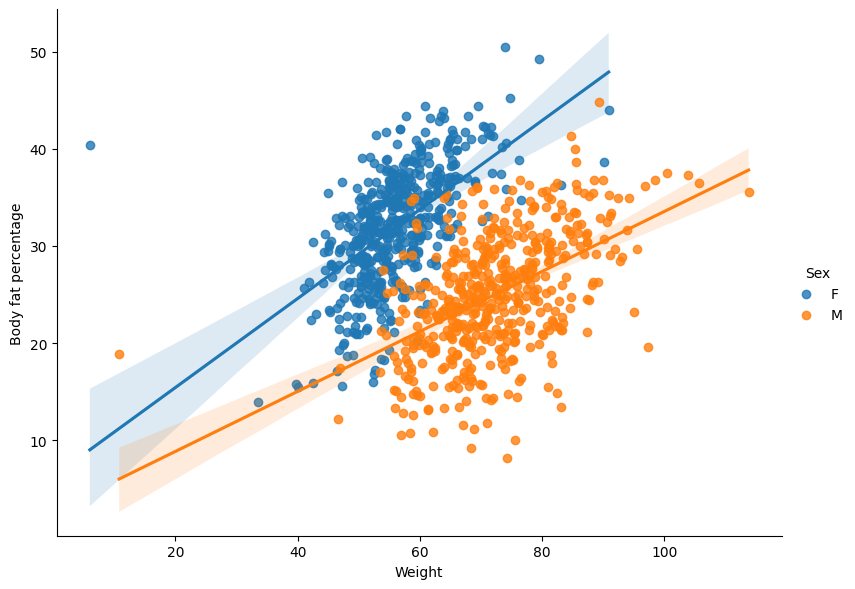

In [14]:
sns.lmplot(data=body_df, x='Weight', y='Body fat percentage', hue='Sex', height=6, aspect=8/6)
plt.show()

In [36]:
penguins=sns.load_dataset('penguins').dropna()

In [37]:
penguins.corr(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


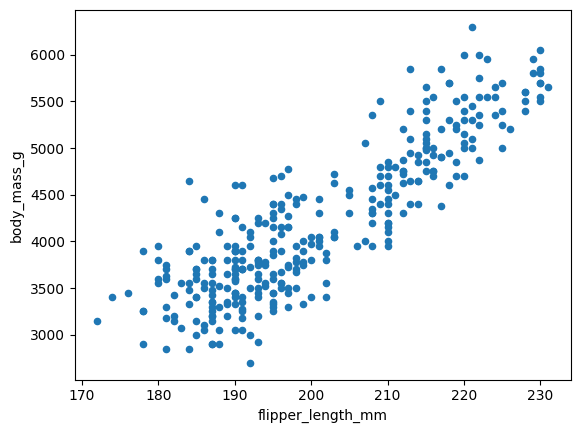

In [38]:
penguins.plot.scatter(x='flipper_length_mm', y='body_mass_g')
plt.show()

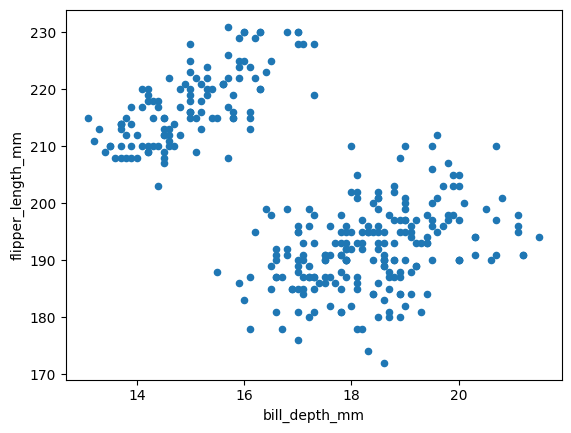

In [39]:
penguins.plot.scatter(x='bill_depth_mm', y='flipper_length_mm')
plt.show()

In [40]:
penguins[['flipper_length_mm', 'bill_length_mm']].cov(ddof=0)

,flipper_length_mm,bill_length_mm
flipper_length_mm,195.851762,49.907870
bill_length_mm,49.907870,29.816525


In [41]:
penguins['bill_length_cm']=penguins['bill_length_mm']/10
penguins['flipper_length_cm']=penguins['flipper_length_mm']/10
penguins[['flipper_length_mm','bill_length_mm']].cov(ddof=0)

,flipper_length_mm,bill_length_mm
flipper_length_mm,195.851762,49.907870
bill_length_mm,49.907870,29.816525


In [42]:
penguins['flipper_length_cm'].cov(penguins['bill_length_cm'],ddof=0)

np.float64(0.4990787003219436)

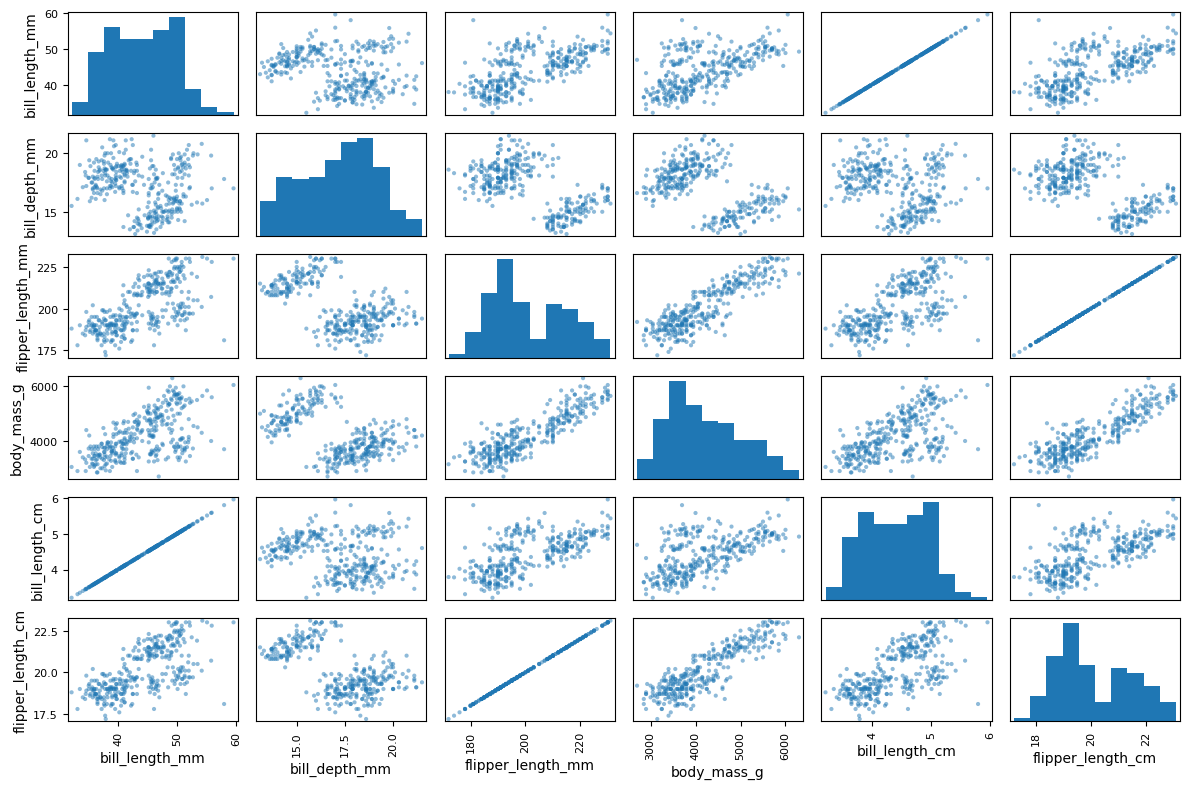

In [44]:
from pandas.plotting import scatter_matrix

axs=scatter_matrix(penguins, figsize=(12,8))
plt.tight_layout()
plt.show()

In [45]:
penguins.corr(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,bill_length_cm,flipper_length_cm
bill_length_mm,1.000000,-0.228626,0.653096,0.589451,1.000000,0.653096
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016,-0.228626,-0.577792
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979,0.653096,1.000000
body_mass_g,0.589451,-0.472016,0.872979,1.000000,0.589451,0.872979
bill_length_cm,1.000000,-0.228626,0.653096,0.589451,1.000000,0.653096
flipper_length_cm,0.653096,-0.577792,1.000000,0.872979,0.653096,1.000000


In [46]:
flip=penguins['flipper_length_cm']
penguins['flipper_pengin']=(flip-flip.mean())/np.std(flip)
penguins.corr(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,bill_length_cm,flipper_length_cm,flipper_pengin
bill_length_mm,1.000000,-0.228626,0.653096,0.589451,1.000000,0.653096,0.653096
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016,-0.228626,-0.577792,-0.577792
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979,0.653096,1.000000,1.000000
body_mass_g,0.589451,-0.472016,0.872979,1.000000,0.589451,0.872979,0.872979
bill_length_cm,1.000000,-0.228626,0.653096,0.589451,1.000000,0.653096,0.653096
flipper_length_cm,0.653096,-0.577792,1.000000,0.872979,0.653096,1.000000,1.000000
flipper_pengin,0.653096,-0.577792,1.000000,0.872979,0.653096,1.000000,1.000000


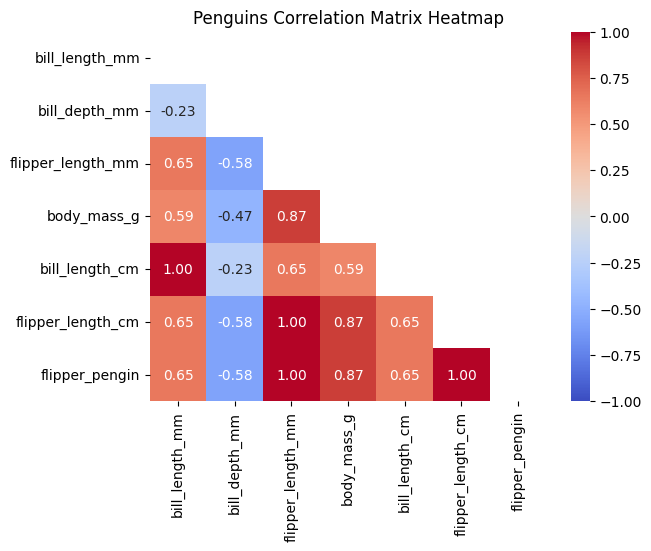

In [48]:
import seaborn as sns
import numpy as np
corr_matrix=penguins.corr(numeric_only=True)
mask=np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, mask=mask)
plt.title('Penguins Correlation Matrix Heatmap')
plt.show()

In [49]:
sc_weir_df = pd.read_csv(data_url+'sc_weir.csv')
sc_weir_df

,Chl-a,Discharge
0,51,25
1,51,25
2,53,24
3,53,24
4,54,22
...,...,...
95,122,9
96,122,9
97,124,49
98,125,9


In [50]:
sc_weir_arr = sc_weir_df.values
sc_weir_arr.shape
chl_a_arr = sc_weir_arr[:, 0]
discharge_arr = sc_weir_arr[:, 1]

In [56]:
np.cov(sc_weir_arr, ddof=0)

array([[ 169.  ,  169.  ,  188.5 , ...,  487.5 ,  754.  ,  747.5 ],
       [ 169.  ,  169.  ,  188.5 , ...,  487.5 ,  754.  ,  747.5 ],
       [ 188.5 ,  188.5 ,  210.25, ...,  543.75,  841.  ,  833.75],
       ...,
       [ 487.5 ,  487.5 ,  543.75, ..., 1406.25, 2175.  , 2156.25],
       [ 754.  ,  754.  ,  841.  , ..., 2175.  , 3364.  , 3335.  ],
       [ 747.5 ,  747.5 ,  833.75, ..., 2156.25, 3335.  , 3306.25]],
      shape=(100, 100))

In [59]:
np.corrcoef(sc_weir_arr, rowvar=False)

array([[ 1.       , -0.4634439],
       [-0.4634439,  1.       ]])

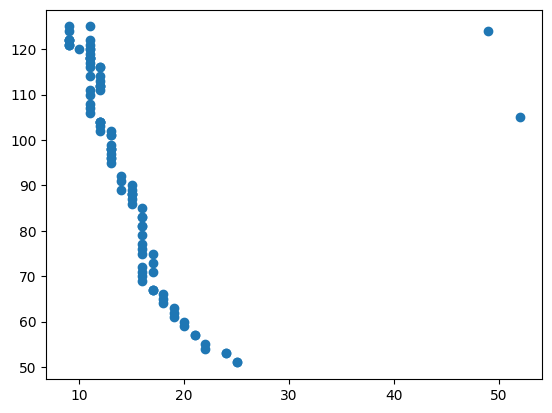

In [60]:
plt.scatter(sc_weir_arr[:,1], sc_weir_arr[:,0])

plt.show()

In [62]:
mask=discharge_arr>40
sc_weir_arr[~mask]

array([[ 51,  25],
       [ 51,  25],
       [ 53,  24],
       [ 53,  24],
       [ 54,  22],
       [ 55,  22],
       [ 57,  21],
       [ 57,  21],
       [ 59,  20],
       [ 60,  20],
       [ 61,  19],
       [ 62,  19],
       [ 63,  19],
       [ 64,  18],
       [ 65,  18],
       [ 66,  18],
       [ 67,  17],
       [ 67,  17],
       [ 67,  17],
       [ 69,  16],
       [ 70,  16],
       [ 71,  16],
       [ 71,  17],
       [ 72,  16],
       [ 73,  17],
       [ 75,  17],
       [ 75,  16],
       [ 76,  16],
       [ 77,  16],
       [ 79,  16],
       [ 81,  16],
       [ 81,  16],
       [ 83,  16],
       [ 83,  16],
       [ 85,  16],
       [ 86,  15],
       [ 87,  15],
       [ 88,  15],
       [ 88,  15],
       [ 88,  15],
       [ 89,  15],
       [ 89,  14],
       [ 90,  15],
       [ 91,  14],
       [ 92,  14],
       [ 95,  13],
       [ 96,  13],
       [ 96,  13],
       [ 97,  13],
       [ 98,  13],
       [ 98,  13],
       [ 98,  13],
       [ 99,